# Assignment 2  Presentation-Quality Figure

Part 2)

I am doing, Gaussian displacement histogram with fit for the data R14-trial2 (2.1 µm beads in acetone)
> Source of Data: "Github\phys332W-sfu\Lab2-Microscopy-and-Motility\Data\2026-03-03\r14-2_1mu-0_5p-4ul-acetone-498ul-trial2.avi"


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import chi2
import os

%matplotlib inline

# Load tracker data 
# File has 3 header lines: #multi:, mass names, t/x/y column labels
# ,
filepath = '../../../Data/2026-03-05/r14-2_1mu-0_5p-4ul-acetone-498ul-trial2-tracker.txt'
raw = np.genfromtxt(filepath, skip_header=3, delimiter=',')

t  = raw[:, 0]
dt = t[1] - t[0]          # time step (s)
n_frames  = len(t)
n_particles = 5

# x-positions at columns 1, 3, 5, 7, 9 (every other column, skipping y)
x_all = raw[:, 1::2][:, :n_particles]

# Frame-to-frame x-displacements, pooled across all particles
all_dx = np.diff(x_all, axis=0).ravel()
all_dx = all_dx[~np.isnan(all_dx)]      # remove NaN from tracking gaps we had

#  3-sigma outlier clipping
def sigma_clip(arr, sigma=3, max_iter=5):
    """Iterative sigma-clipping. Returns clipped array."""
    a = np.array(arr, dtype=float)
    for _ in range(max_iter):
        mu, sd = np.mean(a), np.std(a)
        if sd == 0: break
        mask = np.abs(a - mu) < sigma * sd
        if mask.all(): break
        a = a[mask]
    return a

dx_clipped = sigma_clip(all_dx, sigma=3)

print(f'Dataset: R14-trial2 (2.1 um beads in acetone)')


Dataset: R14-trial2 (2.1 um beads in acetone)


In [16]:
#  Gaussian fit Model

def gaussian_pdf(x, mean, std_dev):
    """Normalized Gaussian PDF."""
    return (1.0 / (np.sqrt(2*np.pi) * abs(std_dev))) * np.exp(-(x - mean)**2 / (2 * std_dev**2))

# Histogram: counts and probability density 
nbins = 25
counts, bins = np.histogram(dx_clipped, bins=nbins)
pdf, _ = np.histogram(dx_clipped, bins=nbins, density=True)
dbins   = np.diff(bins)
bcenter = (bins[:-1] + bins[1:]) / 2.0

# Error bars: Poisson sqrt(N) scaled to density 
Z = np.sum(counts * dbins)
counts_err = np.sqrt(counts) / Z

# Mask zero-count bins for fitting
fit_mask  = counts > 0
bcenter_fit = bcenter[fit_mask]
pdf_fit   = pdf[fit_mask]
err_fit  = counts_err[fit_mask]

# Weighted least-squares Gaussian fit 
p0 = [np.mean(dx_clipped), np.std(dx_clipped)]
pOpt, pCov = curve_fit(gaussian_pdf, bcenter_fit, pdf_fit,
                        p0=p0, sigma=err_fit, absolute_sigma=True)

mu_fit, sigma_fit = pOpt
mu_err   = np.sqrt(pCov[0, 0])
sigma_err = np.sqrt(pCov[1, 1])

# Diffusion coefficient: D = sigma^2 / (2 dt)
D_fit  = sigma_fit**2 / (2.0 * dt)
D_fit_err = 2.0 * abs(sigma_fit) * sigma_err / (2.0 * dt)

# Stokes-Einstein prediction: D_SE = k_B T / (6 pi eta r)
k_B = 1.380649e-23   # J/K
T  = 294.15   # K  (21 C)
eta = 0.32e-3  # Pa s (acetone)
r = 1.05e-6   # m   (2.1 um diameter)
D_SE = k_B * T / (6 * np.pi * eta * r) * 1e12   # um^2/s

# Normalized residuals and chi-squared
normres  = (pdf_fit - gaussian_pdf(bcenter_fit, *pOpt)) / err_fit
chisq  = np.sum(normres**2)
dof     = len(pdf_fit) - 2
chisq_red = chisq / dof
p_value  = 1.0 - chi2.cdf(chisq, dof)


Saved: gaussian_displacement_fit.pdf


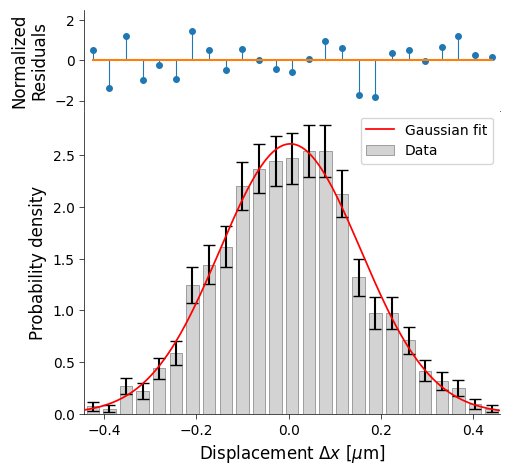

In [ ]:
# Plots
# Formatting follows plot_demo.ipynb + histogram_demo_using_data.ipynb

# Figure size: 80% of 6.5" text width (plot_demo cell-5)
w_text = 6.5
w = 0.8 * w_text                        # 5.2"
h = (2.8 / 3.0) * w                     # ~4.85" (with residual panel)

# Two-panel layout: residuals on top, histogram on bottom (plot_demo cell-6)
f, (a0, a1) = plt.subplots(2, 1, figsize=(w, h),
                            gridspec_kw={'height_ratios': [1, 3]})

# Axes
for ax in [a0, a1]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(0.5)
    ax.spines['left'].set_linewidth(0.5)
    ax.tick_params(width=0.5, labelsize=10)

#Top panel:  residuals 
markerline, stemlines, baseline = a0.stem(
    bcenter_fit, normres, markerfmt='o', basefmt='C1-')
markerline.set_markersize(4)
plt.setp(stemlines, linewidth=0.8)
a0.set_ylabel('Normalized\nResiduals', fontsize=12)
a0.set_xlim(bins[0], bins[-1])
a0.set_ylim(-2.5, 2.5)
a0.set_xticks([])

# Data histogram + Gaussian fit 
# Histogram bars
a1.bar(bcenter, pdf, yerr=counts_err, align='center',
       width=dbins * 0.75, capsize=4, color='lightgray',
       edgecolor='gray', linewidth=0.5, zorder=2, label='Data')

# Gaussian fit curve 
xfine = np.linspace(bins[0], bins[-1], 200)
a1.plot(xfine, gaussian_pdf(xfine, *pOpt), 'r-',
        linewidth=1.25, zorder=3, label='Gaussian fit')

# Labels 
a1.set_xlabel(r'Displacement $\Delta x$ [$\mu$m]', fontsize=12)
a1.set_ylabel('Probability density', fontsize=12)
a1.set_xlim(bins[0], bins[-1])
a1.legend(fontsize=10, loc='upper right')



# Finishing
f.tight_layout()
f.subplots_adjust(hspace=0)

# Export PDF vector graphics
f.savefig('gaussian_displacement_fit.pdf', format='pdf',
          bbox_inches='tight', transparent=True)
print(f'Saved: gaussian_displacement_fit.pdf')

**Figure 1.** Frame-to-frame $x$-displacement histogram for Slide R-14, 2.1 $\mu$ m polystyrene beads in pure acetone. 